In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import math

import matplotlib as mpl
mpl.rcParams.update({
    "font.family": "serif",
    "mathtext.fontset": "cm",
})

In [38]:
XXSMALL_SIZE = 8
XSMALL_SIZE = 12
SMALL_SIZE = 16
MEDIUM_SIZE = 18
BIGGER_SIZE = 20

plt.rc('font', size=MEDIUM_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=MEDIUM_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=MEDIUM_SIZE)    # legend fontsize
plt.rc('figure', titlesize=MEDIUM_SIZE)  # fontsize of the figure title

CB_color_cycle = ['#377eb8', '#ff7f00', '#4daf4a',
                  '#f781bf', '#a65628', '#984ea3',
                  '#999999', '#e41a1c', '#dede00']

colors = [CB_color_cycle[2], CB_color_cycle[4], CB_color_cycle[5], CB_color_cycle[0], CB_color_cycle[7]]
labels = [u"A matches +91\nC-G mismatches -125", "C matches +100\nC-T mismatches -31", "Stellar \u03B5-matches \nMatches +1\nMismatches -e⁻¹"]


## Linear scoring

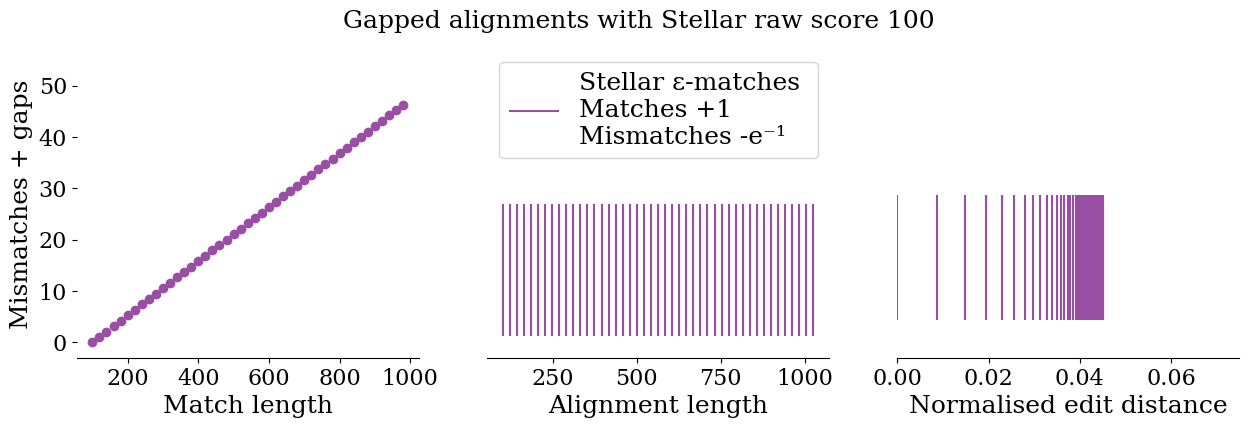

In [184]:
x_list = list(range(100, 1000, 20)) # match count

score = 100
min_len = 100
eps = 0.05

y3 = [(x - score) / (1/eps - 1) for x in x_list] 

fig, axs = plt.subplots(1, 3, sharey = False)
#fig.suptitle('Pairwise local alignment counts', fontsize=BIGGER_SIZE)
fig.set_size_inches(15, 4)

aks = axs[0]
aks.plot(x_list, y3, color = colors[2], marker = 'o', linestyle = "")
aks.set_xlabel("Match length")
aks.set_ylabel("Mismatches + gaps")
aks.set_ylim(-3, 57)

for pos in ['right', 'top', 'left']:
    aks.spines[pos].set_visible(False)

aks = axs[1]
len3 = [sum(x) for x in zip(x_list, y3)]
len3 = [item for item in len3 if item >= min_len]
aks.eventplot(len3, linelengths = 0.15, orientation='horizontal', colors=colors[2], label = labels[2])
aks.set_ylim(0.9, 1.25)
aks.set_xlabel("Alignment length")
aks.legend(loc = "upper center")
aks.set_yticks([])

for pos in ['right', 'top', 'left']:
    aks.spines[pos].set_visible(False)

aks = axs[2]
dist3 = [x[0] / x[1] for x in zip(y3, len3)]
dist3 = [item for item in dist3 if item <= eps]
aks.eventplot(dist3, linelengths = 0.15, orientation='horizontal', colors=colors[2])
aks.set_ylim(0.88, 1.25)
aks.set_xlim(0, 0.075)
aks.set_yticks([])

aks.set_xlabel("Normalised edit distance")

for pos in ['right', 'top', 'left']:
    aks.spines[pos].set_visible(False)

fig.suptitle("Gapped alignments with Stellar raw score " + str(score))
fig.savefig("pohjalik_stellar_score_" + str(score) + ".png", dpi=400, bbox_inches='tight')
plt.show()

## Affine scoring

In [120]:
hoxd = """A C G T 
A  91 –114 –31 –123
C  –114 100 –125 –31 
G  –31 –125 100 –114 
T –123 –31 –114 91"""

In [121]:
hoxd

'A C G T \nA  91 –114 –31 –123\nC  –114 100 –125 –31 \nG  –31 –125 100 –114 \nT –123 –31 –114 91'

In [122]:
def non_negative(l):
    l = [item for item in l if item >= 0]
    return l

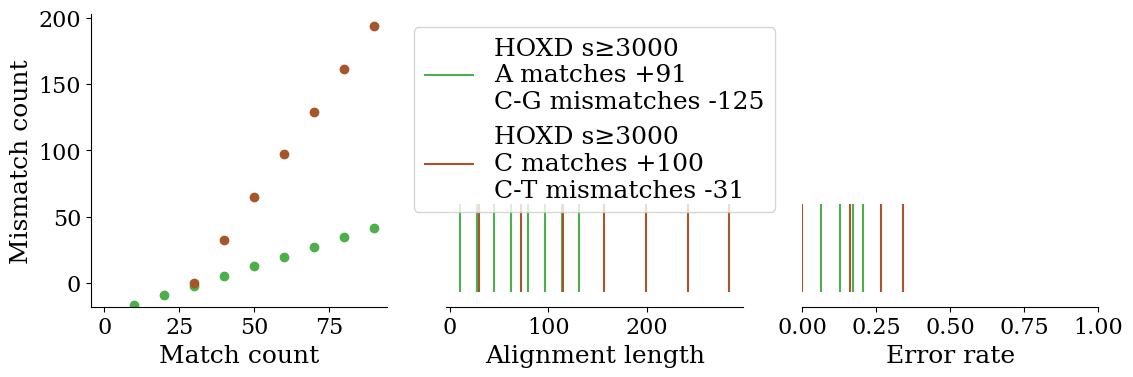

In [182]:
x_list = list(range(0, 100, 10)) # match count
score = 3000

y1 = [(91 * x - score) / 125 for x in x_list] # mismatch count
y2 = [(100 * x - score) / 31 for x in x_list] # mismatch count

fig, axs = plt.subplots(1, 3)
#fig.suptitle('Pairwise local alignment counts', fontsize=BIGGER_SIZE)
fig.set_size_inches(13, 3.8)

aks = axs[0]
aks.plot(x_list, y1, color = colors[0], marker = 'o', linestyle = "")
aks.plot(x_list, y2, color = colors[1], marker = 'o', linestyle = "")

aks.set_ylim(-18, np.max([np.max(y1), np.max(y2)]) + 9)
aks.set_xlabel("Match count")
aks.set_ylabel("Mismatch count")

for pos in ['right', 'top']:
    aks.spines[pos].set_visible(False)

# Alignment length
len1 = [sum(x) for x in zip(x_list, y1)]
len1 = non_negative(len1)
len2 = [sum(x) for x in zip(x_list, y2)]
len2 = non_negative(len2)

aks = axs[1]
aks.eventplot(len1, linelengths = 0.15, orientation='horizontal', colors=colors[0], label = labels[0])
aks.eventplot(len2, linelengths = 0.15, orientation='horizontal', colors=colors[1], label = labels[1])

aks.set_ylim(0.9, 1.4)
aks.set_yticks([])

for pos in ['right', 'top', 'left']:
    aks.spines[pos].set_visible(False)

aks.set_xlabel("Alignment length")
aks.legend(loc = "upper center")

# Edit distance
dist1 = [ x[0] / x[1] for x in zip(y1, len1)]
dist2 = [x[0] / x[1] for x in zip(y2, len2)]

aks = axs[2]
aks.eventplot(dist1, linelengths = 0.15, orientation='horizontal', colors=colors[0])
aks.eventplot(dist2, linelengths = 0.15, orientation='horizontal', colors=colors[1])

aks.set_ylim(0.9, 1.4)
aks.set_xlim(0, 1)
aks.set_yticks([])
aks.set_xlabel("Error rate")

for pos in ['right', 'top', 'left']:
    aks.spines[pos].set_visible(False)

#fig.suptitle("Ungapped alignments with HOXD70 raw score 1000")
fig.savefig("pohjalik_score_1000.png", dpi=400, bbox_inches='tight')
plt.show()


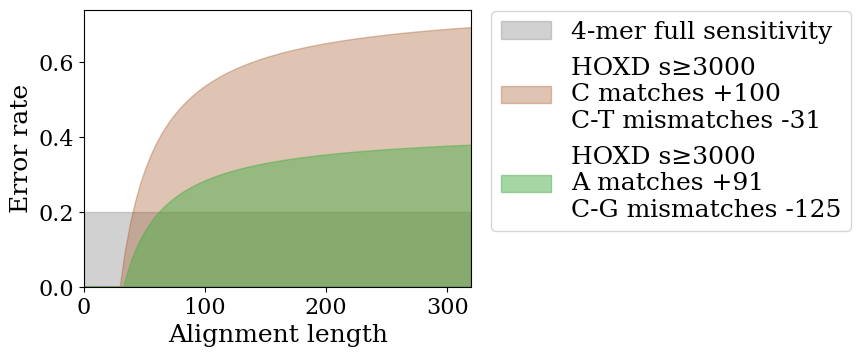

In [35]:
labels = [u"HOXD s\u22653000\nA matches +91\nC-G mismatches -125", u"HOXD s\u22653000\nC matches +100\nC-T mismatches -31"]

x_list = list(range(0, 300, 1)) # match count
score = 3000
y1 = [(91 * x - score) / 125 for x in x_list] # mismatch count
y2 = [(100 * x - score) / 31 for x in x_list] # mismatch count

fig, ax = plt.subplots(1, 1)
#fig.suptitle('Pairwise local alignment counts', fontsize=BIGGER_SIZE)
fig.set_size_inches(5, 3.6)

# Alignment length
len1 = [sum(x) for x in zip(x_list, y1)]
len2 = [sum(x) for x in zip(x_list, y2)]

# Edit distance
dist1 = [ x[0] / x[1] for x in zip(y1, len1)]
dist2 = [x[0] / x[1] for x in zip(y2, len2)]

aks = ax

x_axis = np.arange(0, 320, 1)
aks.fill_between(x_axis, [0]*len(x_axis), [0.2]*len(x_axis), label = "4-mer full sensitivity", color = CB_color_cycle[6], alpha = 0.45)

# Edit distance
#dist2 = [x[0] / x[1] for x in zip(y2, len2)]
aks.fill_between(len2, dist2, [0]*len(x_list), label = labels[1], color = colors[1], alpha = 0.35)

#dist1 = [ x[0] / x[1] for x in zip(y1, len1)]
aks.fill_between(len1, dist1, [0]*len(x_list), label = labels[0], color = colors[0], alpha = 0.5)


#aks.plot(len1, dist1, color = colors[0], marker = 'o', linestyle = "", label = labels[0])
#aks.plot(len2, dist2, color = colors[1], marker = 'o', linestyle = "", label = labels[1])

aks.set_xlim(0, 320)
aks.set_ylim(0, 0.74)
aks.set_xlabel("Alignment length")
aks.set_ylabel("Error rate")

#for pos in ['right', 'top']:
#    aks.spines[pos].set_visible(False)
    
aks.legend(bbox_to_anchor=(1.05, 0.2),
                         loc='lower left', borderaxespad=0.)

#fig.suptitle("Ungapped alignments with HOXD70 raw score 1000")
fig.savefig("hoxd_score_3000.png", dpi=400, bbox_inches='tight')
plt.show()


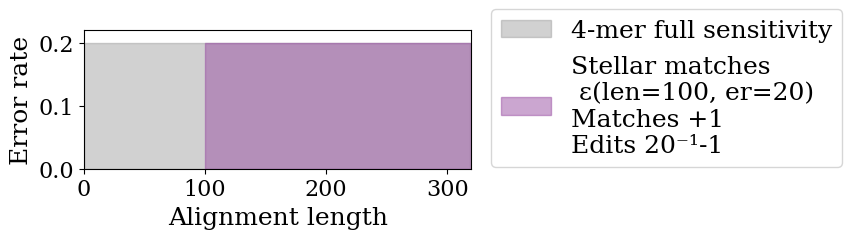

In [73]:
x_list = list(range(100, 1000, 20)) # match count

score = 100
min_len = 100
eps = 0.2

y3 = [(x - score) / (1/eps - 1) for x in x_list] 

labels = ["Stellar matches\n \u03B5(len=" + str(min_len) + ", er=" + str(int(min_len*0.2)) + ") \nMatches +1\nEdits 20⁻¹-1"]

fig, ax = plt.subplots(1, 1)
#fig.suptitle('Pairwise local alignment counts', fontsize=BIGGER_SIZE)
fig.set_size_inches(5, 1.8)

aks = ax
len3 = [sum(x) for x in zip(x_list, y3)]
#len3 = [item for item in len3 if item >= min_len]

dist3 = [x[0] / x[1] for x in zip(y3, len3)]
#dist3 = [item for item in dist3 if item <= eps]

# Alignment length
len3 = [sum(x) for x in zip(x_list, y3)]

# Edit distance
dist1 = [ x[0] / x[1] for x in zip(y3, len3)]

aks = ax

x_axis = np.arange(0, 320, 1)
k = 4
aks.fill_between(x_axis, [0]*len(x_axis), [1/(k+1)]*len(x_axis), label = str(k) + "-mer full sensitivity", color = CB_color_cycle[6], alpha = 0.45)

# Edit distance
#dist1 = [ x[0] / x[1] for x in zip(y1, len1)]
#aks.fill_between(len3, dist3, [0]*len(x_list), label = "Alignment E-value", color = colors[0], alpha = 0.5)
aks.fill_between(len3, [0.2]*len(x_list), [0]*len(x_list), label = labels[0], color = colors[2], alpha = 0.5)

aks.set_xlim(0, 320)
aks.set_ylim(0, 0.22)
aks.set_xlabel("Alignment length")
aks.set_ylabel("Error rate")

#for pos in ['right', 'top']:
#    aks.spines[pos].set_visible(False)
    
aks.legend(bbox_to_anchor=(1.05, 0.01),
                         loc='lower left', borderaxespad=0.)

#fig.suptitle("Gapped alignments with Stellar raw score " + str(score))
fig.savefig("stellar_score_" + str(score) + ".png", dpi=400, bbox_inches='tight')
plt.show()

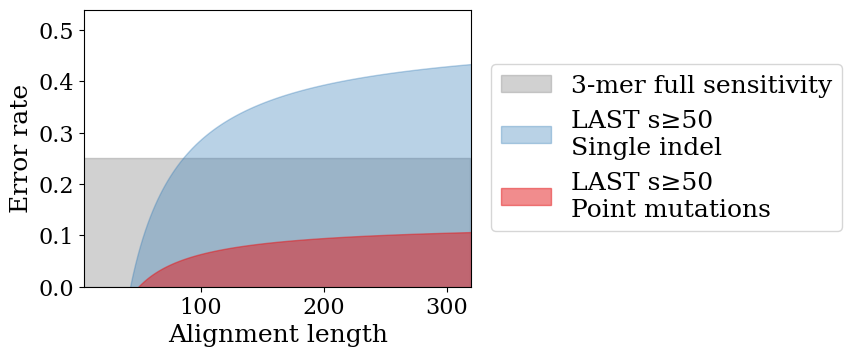

In [70]:
score = 50

labels = [u"LAST s\u2265" + str(score) + "\nPoint mutations", u"LAST s\u2265" + str(score) + "\nSingle indel"]

x_list = list(range(0, 500, 1)) # match count
y1 = [(x - score) / 7 for x in x_list] # mismatch count
y2 = [(x - (score - 7)) / 1 for x in x_list] # mismatch count

fig, ax = plt.subplots(1, 1)
#fig.suptitle('Pairwise local alignment counts', fontsize=BIGGER_SIZE)
fig.set_size_inches(5, 3.6)

# Alignment length
len1 = [sum(x) for x in zip(x_list, y1)]
len2 = [sum(x) for x in zip(x_list, y2)]

# Edit distance
dist1 = [ x[0] / x[1] for x in zip(y1, len1)]
dist2 = [x[0] / x[1] for x in zip(y2, len2)]

aks = ax

x_axis = np.arange(0, 320, 1)
k = 3
aks.fill_between(x_axis, [0]*len(x_axis), [1/(k+1)]*len(x_axis), label = str(k) + "-mer full sensitivity", color = CB_color_cycle[6], alpha = 0.45)

# Edit distance
#dist2 = [x[0] / x[1] for x in zip(y2, len2)]
aks.fill_between(len2, dist2, [-0.01]*len(x_list), label = labels[1], color = colors[3], alpha = 0.35)

#dist1 = [ x[0] / x[1] for x in zip(y1, len1)]
aks.fill_between(len1, dist1, [-0.01]*len(x_list), label = labels[0], color = colors[4], alpha = 0.5)

aks.set_xlim(5, 320)
aks.set_ylim(0, 0.54)
aks.set_xlabel("Alignment length")
aks.set_ylabel("Error rate")

#for pos in ['right', 'top']:
#    aks.spines[pos].set_visible(False)
    
aks.legend(bbox_to_anchor=(1.05, 0.2),
                         loc='lower left', borderaxespad=0.)

#fig.suptitle("Ungapped alignments with HOXD70 raw score 1000")
fig.savefig("last_score_" + str(score) + ".png", dpi=400, bbox_inches='tight')
plt.show()


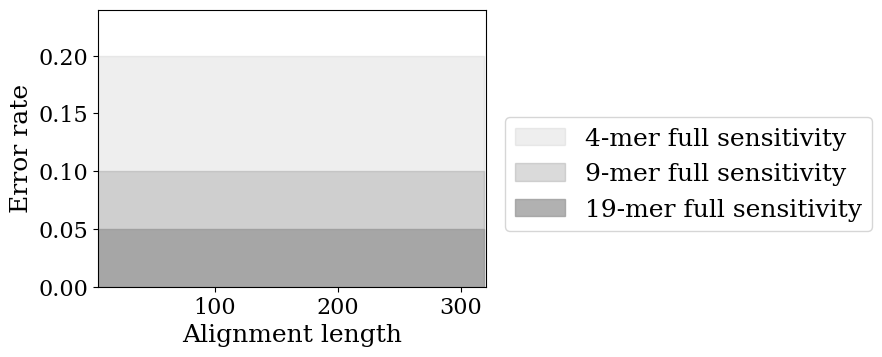

In [72]:
score = 50

x_list = list(range(0, 500, 1)) # match count
y1 = [(x - score) / 7 for x in x_list] # mismatch count
y2 = [(x - (score - 7)) / 1 for x in x_list] # mismatch count

fig, ax = plt.subplots(1, 1)
#fig.suptitle('Pairwise local alignment counts', fontsize=BIGGER_SIZE)
fig.set_size_inches(5, 3.6)

aks = ax

x_axis = np.arange(0, 320, 1)
for k in [4, 9, 19]:
    aks.fill_between(x_axis, [0]*len(x_axis), [1/(k+1)]*len(x_axis), label = str(k) + "-mer full sensitivity", color = CB_color_cycle[6], alpha = k * 4/ 100)

aks.set_xlim(5, 320)
aks.set_ylim(0, 0.24)
aks.set_xlabel("Alignment length")
aks.set_ylabel("Error rate")

#for pos in ['right', 'top']:
#    aks.spines[pos].set_visible(False)
    
aks.legend(bbox_to_anchor=(1.05, 0.2),
                         loc='lower left', borderaxespad=0.)

#fig.suptitle("Ungapped alignments with HOXD70 raw score 1000")
fig.savefig("kmer_sensitivity.png", dpi=400, bbox_inches='tight')
plt.show()
